In [1]:
# Librerías necesarias
import numpy as np
from matplotlib import pyplot
%matplotlib inline


In [2]:

# Cargar dataset local
file_path = "australian.dat"
data = np.loadtxt(file_path)

print("Dimensión del dataset:", data.shape)
print("Primeras 5 filas:")
print(data[:5])


Dimensión del dataset: (690, 15)
Primeras 5 filas:
[[1.000e+00 2.208e+01 1.146e+01 2.000e+00 4.000e+00 4.000e+00 1.585e+00
  0.000e+00 0.000e+00 0.000e+00 1.000e+00 2.000e+00 1.000e+02 1.213e+03
  0.000e+00]
 [0.000e+00 2.267e+01 7.000e+00 2.000e+00 8.000e+00 4.000e+00 1.650e-01
  0.000e+00 0.000e+00 0.000e+00 0.000e+00 2.000e+00 1.600e+02 1.000e+00
  0.000e+00]
 [0.000e+00 2.958e+01 1.750e+00 1.000e+00 4.000e+00 4.000e+00 1.250e+00
  0.000e+00 0.000e+00 0.000e+00 1.000e+00 2.000e+00 2.800e+02 1.000e+00
  0.000e+00]
 [0.000e+00 2.167e+01 1.150e+01 1.000e+00 5.000e+00 3.000e+00 0.000e+00
  1.000e+00 1.000e+00 1.100e+01 1.000e+00 2.000e+00 0.000e+00 1.000e+00
  1.000e+00]
 [1.000e+00 2.017e+01 8.170e+00 2.000e+00 6.000e+00 4.000e+00 1.960e+00
  1.000e+00 1.000e+00 1.400e+01 0.000e+00 2.000e+00 6.000e+01 1.590e+02
  1.000e+00]]


In [3]:

# Separar variables
X = data[:, 0:14]
y = data[:, 14]

print("Forma de X:", X.shape)
print("Forma de y:", y.shape)
print("Clases y cantidades:", np.unique(y, return_counts=True))


Forma de X: (690, 14)
Forma de y: (690,)
Clases y cantidades: (array([0., 1.]), array([383, 307], dtype=int64))


In [4]:

# Mezclar y dividir 75% entrenamiento - 25% prueba
np.random.seed(42)
indices = np.random.permutation(len(X))

X = X[indices]
y = y[indices]

m = len(X)
train_size = int(m * 0.75)

X_train = X[:train_size]
y_train = y[:train_size]

X_test = X[train_size:]
y_test = y[train_size:]

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)


X_train: (517, 14)
X_test : (173, 14)
y_train: (517,)
y_test : (173,)


In [5]:

def featureNormalizeTrain(X):
    X_norm = X.copy().astype(float)
    mu = np.mean(X_norm, axis=0)
    sigma = np.std(X_norm, axis=0)
    sigma[sigma == 0] = 1
    X_norm = (X_norm - mu) / sigma
    return X_norm, mu, sigma

def featureNormalizeTest(X, mu, sigma):
    X_norm = X.copy().astype(float)
    sigma[sigma == 0] = 1
    X_norm = (X_norm - mu) / sigma
    return X_norm


In [6]:

# Normalizar usando SOLO entrenamiento
X_train_norm, mu, sigma = featureNormalizeTrain(X_train)
X_test_norm = featureNormalizeTest(X_test, mu, sigma)

# Agregar término de intercepción
m_train = X_train_norm.shape[0]
m_test = X_test_norm.shape[0]

X_train_b = np.concatenate([np.ones((m_train, 1)), X_train_norm], axis=1)
X_test_b = np.concatenate([np.ones((m_test, 1)), X_test_norm], axis=1)

print("X_train_b:", X_train_b.shape)
print("X_test_b :", X_test_b.shape)


X_train_b: (517, 15)
X_test_b : (173, 15)


## 1. Modelo de regresión lineal

In [7]:

def calcularCostoLineal(theta, X, y):
    m = y.size
    h = X.dot(theta.T)
    J = (1 / (2 * m)) * np.sum((h - y) ** 2)
    return J

def descensoGradienteLineal(theta, X, y, alpha, num_iters):
    m = y.shape[0]
    theta = theta.copy()
    J_history = []

    for i in range(num_iters):
        h = X.dot(theta.T)
        theta = theta - (alpha / m) * (h - y).dot(X)
        J_history.append(calcularCostoLineal(theta, X, y))

    return theta, J_history


Theta lineal:
[ 0.43520309  0.00100585  0.02209746 -0.02524732  0.00630851  0.05925362
  0.01158048  0.03305945  0.29590696  0.05242894  0.03061277 -0.00876855
  0.01035278 -0.02254621  0.05651206]


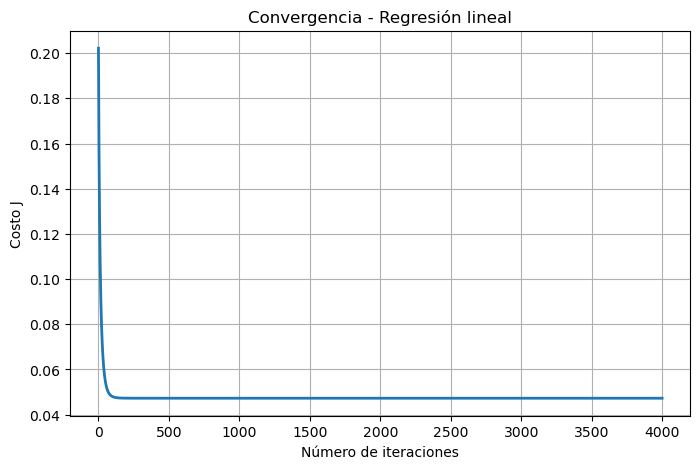

In [8]:

alpha_lin = 0.03
num_iters_lin = 4000
theta_lin = np.zeros(X_train_b.shape[1])

theta_lin, J_history_lin = descensoGradienteLineal(theta_lin, X_train_b, y_train, alpha_lin, num_iters_lin)

print("Theta lineal:")
print(theta_lin)

pyplot.figure(figsize=(8,5))
pyplot.plot(np.arange(len(J_history_lin)), J_history_lin, lw=2)
pyplot.xlabel("Número de iteraciones")
pyplot.ylabel("Costo J")
pyplot.title("Convergencia - Regresión lineal")
pyplot.grid(True)
pyplot.show()


In [9]:

# Predicción regresión lineal
y_pred_train_lin = X_train_b.dot(theta_lin)
y_pred_test_lin = X_test_b.dot(theta_lin)

def mse(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

def rmse(y_true, y_pred):
    return np.sqrt(mse(y_true, y_pred))

def mae(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))

def r2_score_manual(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    return 1 - (ss_res / ss_tot)

print("REGRESIÓN LINEAL - ENTRENAMIENTO")
print("MSE :", mse(y_train, y_pred_train_lin))
print("RMSE:", rmse(y_train, y_pred_train_lin))
print("MAE :", mae(y_train, y_pred_train_lin))
print("R2  :", r2_score_manual(y_train, y_pred_train_lin))

print("\nREGRESIÓN LINEAL - PRUEBA")
print("MSE :", mse(y_test, y_pred_test_lin))
print("RMSE:", rmse(y_test, y_pred_test_lin))
print("MAE :", mae(y_test, y_pred_test_lin))
print("R2  :", r2_score_manual(y_test, y_pred_test_lin))


REGRESIÓN LINEAL - ENTRENAMIENTO
MSE : 0.0945588712225421
RMSE: 0.3075042621209373
MAE : 0.20643153644343162
R2  : 0.6153037118690707

REGRESIÓN LINEAL - PRUEBA
MSE : 0.12344559576120417
RMSE: 0.35134825424527755
MAE : 0.24210334557560342
R2  : 0.5048776151786277


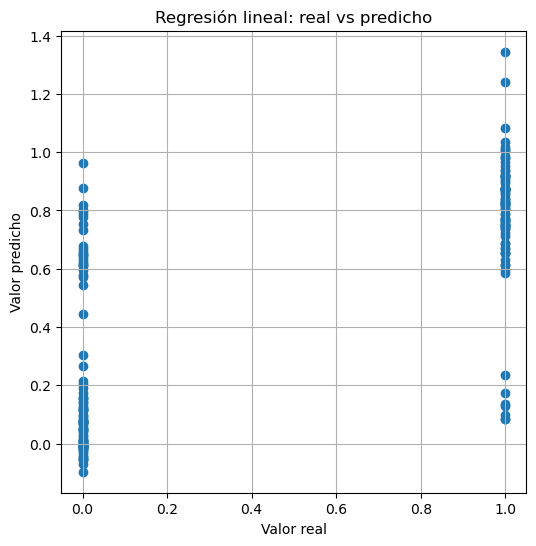

In [10]:

pyplot.figure(figsize=(6,6))
pyplot.scatter(y_test, y_pred_test_lin)
pyplot.xlabel("Valor real")
pyplot.ylabel("Valor predicho")
pyplot.title("Regresión lineal: real vs predicho")
pyplot.grid(True)
pyplot.show()


## 2. Modelo de clasificación: regresión logística

In [11]:
def sigmoid(z):
    z = np.array(z)

    g = np.zeros(z.shape)

    g = 1 / (1 + np.exp(-z))

    return g

In [12]:
def calcularCosto(theta, X, y):
    # Inicializar algunos valores utiles
    m = y.size  # numero de ejemplos de entrenamiento

    J = 0
    h = sigmoid(X.dot(theta.T))
    J = (1 / m) * np.sum(-y.dot(np.log(h)) - (1 - y).dot(np.log(1 - h)))

    return J

In [13]:
def descensoGradiente(theta, X, y, alpha, num_iters):
    # Inicializa algunos valores
    m = y.shape[0] # numero de ejemplos de entrenamiento

    # realiza una copia de theta, el cual será acutalizada por el descenso por el gradiente
    theta = theta.copy()
    J_history = []

    for i in range(num_iters):
        h = sigmoid(X.dot(theta.T))
        theta = theta - (alpha / m) * (h - y).dot(X)

        J_history.append(calcularCosto(theta, X, y))
    return theta, J_history

In [14]:



def predict(theta, X):
    prob = sigmoid(X.dot(theta.T))
    return (prob >= 0.5).astype(int)

def metricas_clasificacion(y_true, y_pred):
    y_true = y_true.astype(int)
    y_pred = y_pred.astype(int)

    TP = np.sum((y_true == 1) & (y_pred == 1))
    TN = np.sum((y_true == 0) & (y_pred == 0))
    FP = np.sum((y_true == 0) & (y_pred == 1))
    FN = np.sum((y_true == 1) & (y_pred == 0))

    accuracy = (TP + TN) / len(y_true)
    precision = TP / (TP + FP) if (TP + FP) != 0 else 0
    recall = TP / (TP + FN) if (TP + FN) != 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) != 0 else 0

    return TP, TN, FP, FN, accuracy, precision, recall, f1


Theta logístico:
[-0.43181858  0.00952521  0.23775478 -0.26923352  0.0470775   0.6359378
  0.11004732  0.34509446  1.7136508   0.28722701  0.47336974 -0.08152072
  0.03800491 -0.2780816   1.52490787]


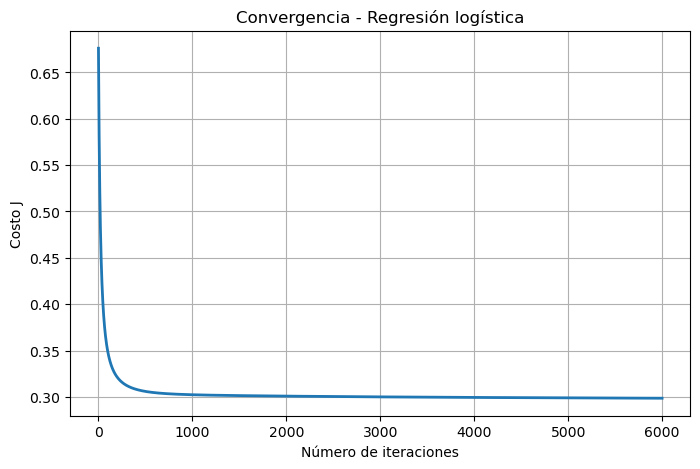

In [15]:

alpha_log = 0.05
num_iters_log = 6000
theta_log = np.zeros(X_train_b.shape[1])

theta_log, J_history_log = descensoGradiente(theta_log, X_train_b, y_train, alpha_log, num_iters_log)

print("Theta logístico:")
print(theta_log)

pyplot.figure(figsize=(8,5))
pyplot.plot(np.arange(len(J_history_log)), J_history_log, lw=2)
pyplot.xlabel("Número de iteraciones")
pyplot.ylabel("Costo J")
pyplot.title("Convergencia - Regresión logística")
pyplot.grid(True)
pyplot.show()


In [16]:

# Predicciones
y_pred_train_log = predict(theta_log, X_train_b)
y_pred_test_log = predict(theta_log, X_test_b)

TP_tr, TN_tr, FP_tr, FN_tr, acc_tr, prec_tr, rec_tr, f1_tr = metricas_clasificacion(y_train, y_pred_train_log)
TP_te, TN_te, FP_te, FN_te, acc_te, prec_te, rec_te, f1_te = metricas_clasificacion(y_test, y_pred_test_log)

print("CLASIFICACIÓN - ENTRENAMIENTO")
print("Accuracy :", acc_tr)
print("Precision:", prec_tr)
print("Recall   :", rec_tr)
print("F1-score :", f1_tr)

print("\nCLASIFICACIÓN - PRUEBA")
print("Accuracy :", acc_te)
print("Precision:", prec_te)
print("Recall   :", rec_te)
print("F1-score :", f1_te)


CLASIFICACIÓN - ENTRENAMIENTO
Accuracy : 0.8781431334622823
Precision: 0.8347107438016529
Recall   : 0.8977777777777778
F1-score : 0.8650963597430407

CLASIFICACIÓN - PRUEBA
Accuracy : 0.838150289017341
Precision: 0.7934782608695652
Recall   : 0.8902439024390244
F1-score : 0.8390804597701148


Matriz de confusión:
[[72 19]
 [ 9 73]]


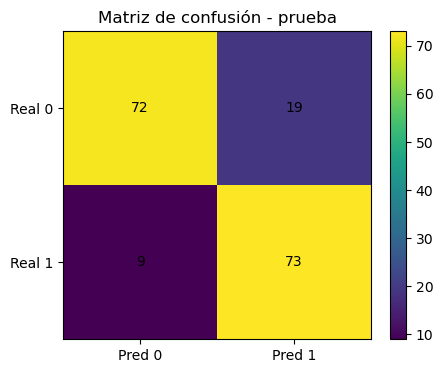

In [17]:

# Matriz de confusión en prueba
conf = np.array([[TN_te, FP_te],
                 [FN_te, TP_te]])

print("Matriz de confusión:")
print(conf)

pyplot.figure(figsize=(5,4))
pyplot.imshow(conf)
pyplot.xticks([0, 1], ["Pred 0", "Pred 1"])
pyplot.yticks([0, 1], ["Real 0", "Real 1"])
pyplot.title("Matriz de confusión - prueba")

for i in range(2):
    for j in range(2):
        pyplot.text(j, i, conf[i, j], ha='center', va='center')

pyplot.colorbar()
pyplot.show()


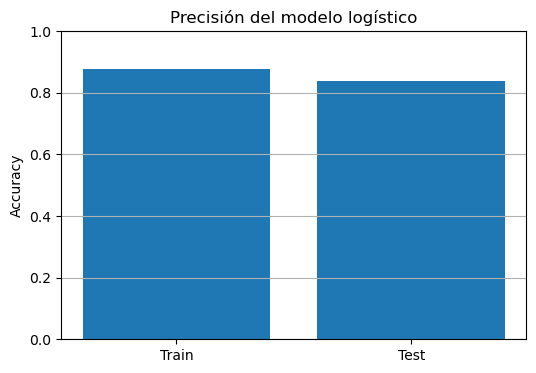

In [18]:

# Comparación simple entre entrenamiento y prueba
pyplot.figure(figsize=(6,4))
pyplot.bar(["Train", "Test"], [acc_tr, acc_te])
pyplot.ylim(0, 1)
pyplot.ylabel("Accuracy")
pyplot.title("Precisión del modelo logístico")
pyplot.grid(axis="y")
pyplot.show()



## Breve explicación final

- Se cargó el archivo `australian.dat` y se separaron 14 variables de entrada y 1 variable objetivo.
- La división del dataset fue **75% entrenamiento** y **25% prueba**
- Se normalizaron las variables usando solo el conjunto de entrenamiento para evitar fuga de información.
- Se aplicaron dos modelos:
  1. **Regresión lineal**, evaluada con MSE, RMSE, MAE y R².
  2. **Regresión logística para clasificación**, evaluada con accuracy, precision, recall, F1-score y matriz de confusión.
- Para reducir el sobreajuste, la evaluación final se hizo sobre el conjunto de prueba y se comparó entrenamiento contra prueba.
- El modelo de **clasificación logística** es el más adecuado para este dataset porque la salida real es binaria: **0 o 1**.
